# Compare_Real_Generated_DDM_Params_v2.4.3_V2

这个 notebook 是针对 Self-Matching Task 的 **Matching-only 合理比较版**。

核心思路：

1. 真实实验来自 Sui (2012) 风格的 Self-Matching Task，真实数据同时包含 `Matching` 和 `NonMatching`。
2. 当前生成模型 `v2.4.3` 的理论设定是：**只在 Matching 条件下** 比较 `self` 和 `stranger` 的 SPE。
3. 因此，真实数据与生成数据的主比较必须建立在 **真实数据的 Matching 试次** 上，而不是全部试次。

本 notebook 会完成三件事：

1. 根据实验代码和真实数据，恢复每个 trial 的 `Matching / NonMatching`。
2. 只使用 Matching 试次，对真实数据与生成数据分别估计 `v / a / t / z`。
3. 比较真实数据估计参数、生成数据行为反推参数、生成模型潜在参数三者的趋势是否一致。

重要说明：

- 真实数据 `T / W` 是秒，这里统一转成毫秒 `ms`。
- `RT` 在参数估计时保留为秒 `s`，因为 EZ-diffusion 输出的 `t` 也是秒。
- 真实数据没有足够信息稳定估计起点偏置，因此这里沿用生成模型的对称假设：`z = a / 2`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 240)

BASE_DIR = Path.cwd().parent.parent
REAL_PATH = BASE_DIR / '2_Data' / 'Real_Data' / 'EXP_data_combined.csv'
GEN_PATH = BASE_DIR / '2_Data' / 'Generate_Data' / 'Generate_Data_v2.4.3_checks' / 'gp_ddm_v2.4.3_large.csv'
CODE_PATH = BASE_DIR / '1_Code' / 'Experiment' / 'exp_matlab' / 'experiment_formal_newcon.m'
CODE_TEST_PATH = BASE_DIR / '1_Code' / 'Experiment' / 'exp_matlab' / 'test' / 'experiment_formal.m'
FIG_DIR = BASE_DIR / '3_Figures' / 'Compare_Real_Generated_DDM_Params_v2.4.3_V2'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('真实数据路径:', REAL_PATH)
print('生成数据路径:', GEN_PATH)
print('实验代码路径:', CODE_PATH)
print('图表输出目录:', FIG_DIR)

真实数据路径: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Real_Data\EXP_data_combined.csv
生成数据路径: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.3_checks\gp_ddm_v2.4.3_large.csv
实验代码路径: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Experiment\exp_matlab\experiment_formal_newcon.m
图表输出目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Compare_Real_Generated_DDM_Params_v2.4.3_V2


## 一、先确认实验代码版本与 Matching 逻辑

In [2]:
formal_code = CODE_PATH.read_text(encoding='utf-8', errors='ignore')
test_code = CODE_TEST_PATH.read_text(encoding='utf-8', errors='ignore')

print('experiment_formal_newcon.m exists:', CODE_PATH.exists())
print('test/experiment_formal.m exists:', CODE_TEST_PATH.exists())
print('formal_newcon size:', CODE_PATH.stat().st_size)
print('test formal size   :', CODE_TEST_PATH.stat().st_size)
print('formal_newcon mtime:', pd.to_datetime(CODE_PATH.stat().st_mtime, unit='s'))
print('test formal mtime  :', pd.to_datetime(CODE_TEST_PATH.stat().st_mtime, unit='s'))

keywords = ['matchingStimuli', 'nonMatchingStimuli', 'getMatchKey', 'getPairingRules', 'CorrectKey']
for key in keywords:
    print(key, 'in formal_newcon =', key in formal_code, '| in test =', key in test_code)

experiment_formal_newcon.m exists: True
test/experiment_formal.m exists: True
formal_newcon size: 38077
test formal size   : 37995
formal_newcon mtime: 2025-04-18 12:37:04
test formal mtime  : 2025-03-23 12:13:14
matchingStimuli in formal_newcon = True | in test = True
nonMatchingStimuli in formal_newcon = True | in test = True
getMatchKey in formal_newcon = True | in test = True
getPairingRules in formal_newcon = True | in test = True
CorrectKey in formal_newcon = True | in test = True


### 代码判断

从文件结构与导出格式来看，真实实验实际使用的主版本高度疑似是：

- `1_Code/Experiment/exp_matlab/experiment_formal_newcon.m`

理由：

- 它包含与真实数据完全一致的导出列名：`groupID, subjectID, ..., Shape, Label, CorrectKey, Response, RT, Correct`。
- 它明确构造了 `matchingStimuli` 与 `nonMatchingStimuli`。
- 它定义了 `getMatchKey(subjectID)`，也就是 Matching / NonMatching 的按键规则。
- `test/experiment_formal.m` 与其逻辑几乎相同，更像早期测试或备份副本。

不过，后面我们会看到真实数据中至少有一个被试（`group2_11`）的 `CorrectKey` 组合与 `getPairingRules(subjectID)` 的硬编码不完全一致。因此：

- 我们可以认为 **主体代码版本** 是 `experiment_formal_newcon.m`；
- 但在恢复 `Matching` 时，最稳妥的方法不是死板套用 `pairingRules`，而是使用真实数据里已经保存的 `CorrectKey`。

In [3]:
# 读取真实与生成数据
real_raw = pd.read_csv(REAL_PATH)
gen_raw = pd.read_csv(GEN_PATH)

print('real_raw shape:', real_raw.shape)
print('gen_raw shape :', gen_raw.shape)
display(real_raw.head())
display(gen_raw.head())

real_raw shape: (26616, 18)
gen_raw shape : (120000, 19)


,groupID,subjectID,gender,age,handedness,stage,trialID,P,T,W,Shape,Label,CorrectKey,Response,RT,Correct,SourceFile,GroupInfo
0,1,1,1,23,2,formal,1,0,0.03,0.3,square,self,j,NaN,NaN,0,EXP_data_group1_1.csv,group1_1
1,1,1,1,23,2,formal,2,0,0.03,0.3,square,stranger,f,NaN,NaN,0,EXP_data_group1_1.csv,group1_1
2,1,1,1,23,2,formal,3,0,0.03,0.3,circle,self,f,f,0.23854,1,EXP_data_group1_1.csv,group1_1
3,1,1,1,23,2,formal,4,0,0.03,0.3,circle,stranger,j,NaN,NaN,0,EXP_data_group1_1.csv,group1_1
4,1,1,1,23,2,formal,5,0,0.03,0.3,square,self,j,NaN,NaN,0,EXP_data_group1_1.csv,group1_1


,subject,trial,P,T,W,M,label,v,a,t0,z,RT,response,v_s2,a_s2,v_gp_raw,a_gp_raw,v_mix,a_mix
0,1,1,142,480,1315,1795,stranger,-0.573219,3.363554,0.2,1.681777,1.164,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
1,1,2,142,480,1315,1795,stranger,1.241587,2.123674,0.2,1.061837,1.010,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
2,1,3,142,480,1315,1795,stranger,2.712455,2.699411,0.2,1.349705,0.468,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
3,1,4,142,480,1315,1795,stranger,0.337516,2.430360,0.2,1.215180,0.781,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
4,1,5,142,480,1315,1795,stranger,1.515241,3.038043,0.2,1.519021,1.795,0,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338


In [4]:
# 根据代码恢复 matchKey，并据此定义 Matching
def get_match_key(subject_id):
    # 代码中 getMatchKey(subjectID) = {f, j, j, f} 循环
    keys = ['f', 'j', 'j', 'f']
    return keys[(int(subject_id) - 1) % 4]

real = real_raw.copy()
real = real.rename(columns={'subjectID': 'subject', 'Label': 'label', 'Correct': 'correct', 'RT': 'rt_s'})
real['subject_uid'] = real['GroupInfo'].astype(str)
real['label'] = real['label'].astype(str).str.lower()
real['shape'] = real['Shape'].astype(str).str.lower()
real['CorrectKey'] = real['CorrectKey'].astype(str).str.lower()
real['Response'] = real['Response'].astype(str).str.lower()
real['match_key'] = real['subject'].apply(get_match_key)
real['matching'] = np.where(real['CorrectKey'] == real['match_key'], 'Matching', 'NonMatching')
real['T_ms'] = pd.to_numeric(real['T'], errors='coerce') * 1000.0
real['W_ms'] = pd.to_numeric(real['W'], errors='coerce') * 1000.0
real['rt_s'] = pd.to_numeric(real['rt_s'], errors='coerce')
real['correct'] = pd.to_numeric(real['correct'], errors='coerce').fillna(0).astype(int)

print('Matching / NonMatching counts:')
display(real['matching'].value_counts())
print('Matching by Shape × Label:')
display(pd.crosstab([real['shape'], real['label']], real['matching']))

Matching / NonMatching counts:


matching
NonMatching    13308
Matching       13308
Name: count, dtype: int64

Matching by Shape × Label:


matching         Matching  NonMatching
shape  label                          
circle self          3328         3326
       stranger      3326         3328
square self          3326         3328
       stranger      3328         3326

In [5]:
# 用代码中的 getPairingRules 做一个诊断，看看和真实数据里保存的 CorrectKey 一致到什么程度
def pairing_rule_key(shape, label, subject_id):
    mod_result = int(subject_id) % 4
    if mod_result == 0:
        rules = {('square', 'self'): 'f', ('square', 'stranger'): 'j', ('circle', 'self'): 'j', ('circle', 'stranger'): 'f'}
    elif mod_result == 1:
        rules = {('square', 'self'): 'j', ('square', 'stranger'): 'f', ('circle', 'self'): 'f', ('circle', 'stranger'): 'j'}
    elif mod_result == 2:
        rules = {('square', 'self'): 'j', ('square', 'stranger'): 'f', ('circle', 'self'): 'f', ('circle', 'stranger'): 'j'}
    else:
        rules = {('square', 'self'): 'f', ('square', 'stranger'): 'j', ('circle', 'self'): 'j', ('circle', 'stranger'): 'f'}
    return rules[(shape, label)]

real['CorrectKey_rule'] = real.apply(lambda r: pairing_rule_key(r['shape'], r['label'], r['subject']), axis=1)
real['rule_match'] = real['CorrectKey_rule'] == real['CorrectKey']

print('CorrectKey 与硬编码 pairingRules 的整体一致率:')
print(real['rule_match'].mean())
print('\n按 GroupInfo 查看不一致情况（只显示不一致的文件）:')
rule_diag = real.groupby('subject_uid')['rule_match'].mean().sort_values()
display(rule_diag[rule_diag < 1.0].head(10))

CorrectKey 与硬编码 pairingRules 的整体一致率:
0.9804628794709949

按 GroupInfo 查看不一致情况（只显示不一致的文件）:


subject_uid
group2_11    0.0
Name: rule_match, dtype: float64

### 这里的关键判断

1. 真实数据确实同时包含 `Matching` 和 `NonMatching`，并且数量基本各半。
2. 合并后的真实数据原表中没有 `Matching` 列，但可以稳定恢复：

   `Matching = (CorrectKey == getMatchKey(subjectID))`

3. 这一定义比直接套用 `pairingRules(shape, label, subjectID)` 更稳，因为真实导出文件里已经保存了每个 trial 的 `CorrectKey`，它更接近“实际运行版本”的真实结果。
4. 因为生成模型只模拟 Matching 下的 `self vs stranger`，所以主分析应该只使用真实数据中的 `Matching` 试次。

## 二、构造用于比较的真实 Matching 数据与生成数据

In [6]:
# 真实数据：只保留 formal + Matching
real_match = real.copy()
if 'stage' in real_match.columns:
    real_match = real_match[real_match['stage'].astype(str).str.lower() == 'formal'].copy()
real_match = real_match[real_match['matching'] == 'Matching'].copy()
real_match['dataset'] = 'real_matching'

# 生成数据：默认就是 Matching 模拟
gen = gen_raw.copy()
gen['subject_uid'] = gen['subject'].astype(str)
gen['label'] = gen['label'].astype(str).str.lower()
gen['T_ms'] = pd.to_numeric(gen['T'], errors='coerce')
gen['W_ms'] = pd.to_numeric(gen['W'], errors='coerce')
gen['rt_s'] = pd.to_numeric(gen['RT'], errors='coerce')
gen['correct'] = (pd.to_numeric(gen['response'], errors='coerce') == 1).astype(int)
gen['matching'] = 'Matching'
gen['dataset'] = 'generated_matching'

print('真实 Matching 数据 shape:', real_match.shape)
print('生成数据 shape:', gen.shape)
display(real_match.head())
display(gen.head())

真实 Matching 数据 shape: (11960, 27)
生成数据 shape: (120000, 26)


,groupID,subject,gender,age,handedness,stage,trialID,P,T,W,Shape,label,CorrectKey,Response,rt_s,correct,SourceFile,GroupInfo,subject_uid,shape,match_key,matching,T_ms,W_ms,CorrectKey_rule,rule_match,dataset
1,1,1,1,23,2,formal,2,0,0.03,0.3,square,stranger,f,nan,NaN,0,EXP_data_group1_1.csv,group1_1,group1_1,square,f,Matching,30.0,300.0,f,True,real_matching
2,1,1,1,23,2,formal,3,0,0.03,0.3,circle,self,f,f,0.23854,1,EXP_data_group1_1.csv,group1_1,group1_1,circle,f,Matching,30.0,300.0,f,True,real_matching
5,1,1,1,23,2,formal,6,0,0.03,0.3,square,stranger,f,nan,NaN,0,EXP_data_group1_1.csv,group1_1,group1_1,square,f,Matching,30.0,300.0,f,True,real_matching
6,1,1,1,23,2,formal,7,0,0.03,0.3,circle,self,f,nan,NaN,0,EXP_data_group1_1.csv,group1_1,group1_1,circle,f,Matching,30.0,300.0,f,True,real_matching
8,1,1,1,23,2,formal,9,0,0.03,0.3,square,stranger,f,nan,NaN,0,EXP_data_group1_1.csv,group1_1,group1_1,square,f,Matching,30.0,300.0,f,True,real_matching


,subject,trial,P,T,W,M,label,v,a,t0,z,RT,response,v_s2,a_s2,v_gp_raw,a_gp_raw,v_mix,a_mix,subject_uid,T_ms,W_ms,rt_s,correct,matching,dataset
0,1,1,142,480,1315,1795,stranger,-0.573219,3.363554,0.2,1.681777,1.164,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338,1,480,1315,1.164,1,Matching,generated_matching
1,1,2,142,480,1315,1795,stranger,1.241587,2.123674,0.2,1.061837,1.010,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338,1,480,1315,1.010,1,Matching,generated_matching
2,1,3,142,480,1315,1795,stranger,2.712455,2.699411,0.2,1.349705,0.468,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338,1,480,1315,0.468,1,Matching,generated_matching
3,1,4,142,480,1315,1795,stranger,0.337516,2.430360,0.2,1.215180,0.781,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338,1,480,1315,0.781,1,Matching,generated_matching
4,1,5,142,480,1315,1795,stranger,1.515241,3.038043,0.2,1.519021,1.795,0,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338,1,480,1315,1.795,0,Matching,generated_matching


In [7]:
# 真实实验条件（毫秒）
real_conditions = (
    real_match[['P', 'T_ms', 'W_ms']]
      .drop_duplicates()
      .sort_values(['P', 'T_ms', 'W_ms'])
      .reset_index(drop=True)
)
real_conditions['condition_id'] = [f'C{i+1}' for i in range(len(real_conditions))]
display(real_conditions)

real_match = real_match.merge(real_conditions, on=['P', 'T_ms', 'W_ms'], how='left')

,P,T_ms,W_ms,condition_id
0,0,30.0,300.0,C1
1,0,30.0,600.0,C2
2,8,100.0,1100.0,C3
3,120,30.0,600.0,C4
4,120,80.0,600.0,C5
5,120,500.0,1500.0,C6


In [8]:
# 生成数据是连续采样，所以映射到最近的真实条件
scale_P = max(real_conditions['P'].max() - real_conditions['P'].min(), 1)
scale_T = max(real_conditions['T_ms'].max() - real_conditions['T_ms'].min(), 1)
scale_W = max(real_conditions['W_ms'].max() - real_conditions['W_ms'].min(), 1)

gen_subject_conditions = gen[['subject', 'P', 'T_ms', 'W_ms']].drop_duplicates().copy()

def nearest_real_condition(row):
    d = (
        ((real_conditions['P'] - row['P']) / scale_P) ** 2
        + ((real_conditions['T_ms'] - row['T_ms']) / scale_T) ** 2
        + ((real_conditions['W_ms'] - row['W_ms']) / scale_W) ** 2
    )
    idx = d.idxmin()
    return real_conditions.loc[idx, ['condition_id', 'P', 'T_ms', 'W_ms']]

assigned = gen_subject_conditions.apply(nearest_real_condition, axis=1)
assigned = pd.concat([gen_subject_conditions[['subject']].reset_index(drop=True), assigned.reset_index(drop=True)], axis=1)
assigned = assigned.rename(columns={'P': 'P_target', 'T_ms': 'T_ms_target', 'W_ms': 'W_ms_target'})
gen = gen.merge(assigned, on='subject', how='left')

print('生成 subject 映射到真实条件后的分布:')
display(assigned['condition_id'].value_counts().sort_index())

生成 subject 映射到真实条件后的分布:


condition_id
C1    141
C2     94
C3    504
C4     87
C5    564
C6    610
Name: count, dtype: int64

## 三、参数估计逻辑

这里沿用 EZ-diffusion 近似，从 Matching 试次的行为数据估计 `v / a / t`：

- 对真实数据：在 `Matching`、`label`、`condition` 层面进行估计。
- 对生成数据：
  - 一方面从行为结果反推 `v / a / t / z`；
  - 另一方面直接汇总模型输出的潜在参数 `v / a / t0 / z`。

这样就能比较：真实趋势、生成行为趋势、生成模型内在趋势 三者是否一致。

In [9]:
def ez_diffusion_from_group(df_group, rt_col='rt_s', correct_col='correct', s=0.1):
    n_total = len(df_group)
    if n_total < 4:
        return pd.Series({'pc': np.nan, 'mrt': np.nan, 'vrt': np.nan, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': 0, 'valid_ez': 0})

    pc_raw = df_group[correct_col].mean()
    pc = (df_group[correct_col].sum() + 0.5) / (n_total + 1.0)
    pc = float(np.clip(pc, 1e-4, 1 - 1e-4))

    correct_rt = df_group.loc[(df_group[correct_col] == 1) & df_group[rt_col].notna(), rt_col]
    n_correct_rt = len(correct_rt)
    if n_correct_rt < 3:
        return pd.Series({'pc': pc_raw, 'mrt': np.nan, 'vrt': np.nan, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    mrt = correct_rt.mean()
    vrt = correct_rt.var(ddof=1)
    if (pc <= 0.5) or (vrt <= 0) or np.isnan(vrt):
        return pd.Series({'pc': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    logit_p = np.log(pc / (1 - pc))
    x = logit_p * (pc**2 * logit_p - pc * logit_p + pc - 0.5) / vrt
    if x <= 0 or np.isnan(x):
        return pd.Series({'pc': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    v = s * np.power(x, 0.25)
    if v == 0 or np.isnan(v):
        return pd.Series({'pc': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    a = (s ** 2) * logit_p / v
    y = (-v * a) / (s ** 2)
    mdt = (a / (2 * v)) * ((1 - np.exp(y)) / (1 + np.exp(y)))
    ter = mrt - mdt
    z = a / 2.0

    valid = int((not np.any(np.isnan([v, a, ter, z]))) and (a > 0) and (ter >= 0))
    return pd.Series({'pc': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': v if valid else np.nan, 'a_est': a if valid else np.nan, 't_est': ter if valid else np.nan, 'z_est': z if valid else np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': valid})

In [10]:
def estimate_params(df, dataset_name):
    if dataset_name == 'real_matching':
        group_cols = ['subject_uid', 'condition_id', 'P', 'T_ms', 'W_ms', 'label']
    else:
        group_cols = ['subject_uid', 'condition_id', 'P_target', 'T_ms_target', 'W_ms_target', 'label']

    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(ez_diffusion_from_group(g).to_dict())
        rows.append(row)
    out = pd.DataFrame(rows)
    out['dataset'] = dataset_name

    if dataset_name == 'generated_matching':
        latent = (
            df.groupby(group_cols, as_index=False)
              .agg(
                  v_latent=('v', 'mean'),
                  a_latent=('a', 'mean'),
                  t_latent=('t0', 'mean'),
                  z_latent=('z', 'mean'),
              )
        )
        out = out.merge(latent, on=group_cols, how='left')
    return out

In [11]:
real_est = estimate_params(real_match, 'real_matching')
gen_est = estimate_params(gen, 'generated_matching')

print('真实 Matching 数据 EZ 有效估计：')
display(real_est['valid_ez'].value_counts(dropna=False))
print('生成数据 EZ 有效估计：')
display(gen_est['valid_ez'].value_counts(dropna=False))
display(real_est.head())
display(gen_est.head())

真实 Matching 数据 EZ 有效估计：


valid_ez
0.0    53
1.0    39
Name: count, dtype: int64

生成数据 EZ 有效估计：


valid_ez
1.0    3789
0.0     211
Name: count, dtype: int64

,subject_uid,condition_id,P,T_ms,W_ms,label,pc,mrt,vrt,v_est,a_est,t_est,z_est,n_total,n_correct_rt,valid_ez,dataset
0,group1_1,C1,0,30.0,300.0,self,0.146154,0.263868,0.001193,NaN,NaN,NaN,NaN,130.0,19.0,0.0,real_matching
1,group1_1,C1,0,30.0,300.0,stranger,0.084615,0.252243,0.000853,NaN,NaN,NaN,NaN,130.0,11.0,0.0,real_matching
2,group1_2,C1,0,30.0,300.0,self,0.176923,0.275991,0.001247,NaN,NaN,NaN,NaN,130.0,23.0,0.0,real_matching
3,group1_2,C1,0,30.0,300.0,stranger,0.146154,0.269485,0.001245,NaN,NaN,NaN,NaN,130.0,19.0,0.0,real_matching
4,group1_3,C1,0,30.0,300.0,self,0.130769,0.266592,0.000878,NaN,NaN,NaN,NaN,130.0,17.0,0.0,real_matching


,subject_uid,condition_id,P_target,T_ms_target,W_ms_target,label,pc,mrt,vrt,v_est,a_est,t_est,z_est,n_total,n_correct_rt,valid_ez,dataset,v_latent,a_latent,t_latent,z_latent
0,1,C6,120,500.0,1500.0,self,1.000000,0.571433,0.047952,0.244761,0.167955,0.239401,0.083977,30.0,30.0,1.0,generated_matching,3.749712,2.368134,0.2,1.184067
1,1,C6,120,500.0,1500.0,stranger,0.766667,0.872000,0.147735,0.078292,0.145877,0.391160,0.072939,30.0,23.0,1.0,generated_matching,1.191880,2.543808,0.2,1.271904
2,10,C1,0,30.0,300.0,self,0.766667,0.436783,0.084073,0.090141,0.126701,0.074049,0.063351,30.0,23.0,1.0,generated_matching,1.375776,0.827064,0.2,0.413532
3,10,C1,0,30.0,300.0,stranger,0.533333,0.409500,0.045835,0.012606,0.102498,0.147219,0.051249,30.0,16.0,1.0,generated_matching,0.427163,0.824626,0.2,0.412313
4,100,C5,120,80.0,600.0,self,0.966667,0.569241,0.048784,0.209330,0.142308,0.262224,0.071154,30.0,29.0,1.0,generated_matching,3.124934,2.359418,0.2,1.179709


## 四、条件层面的主比较表

In [12]:
real_cond = (
    real_est[real_est['valid_ez'] == 1]
      .groupby(['condition_id', 'label'], as_index=False)
      .agg(
          P=('P', 'mean'),
          T_ms=('T_ms', 'mean'),
          W_ms=('W_ms', 'mean'),
          v_real=('v_est', 'mean'),
          a_real=('a_est', 'mean'),
          t_real=('t_est', 'mean'),
          z_real=('z_est', 'mean'),
          pc_real=('pc', 'mean'),
          n_real=('subject_uid', 'nunique'),
      )
)

gen_cond_est = (
    gen_est[gen_est['valid_ez'] == 1]
      .groupby(['condition_id', 'label'], as_index=False)
      .agg(
          P=('P_target', 'mean'),
          T_ms=('T_ms_target', 'mean'),
          W_ms=('W_ms_target', 'mean'),
          v_gen_est=('v_est', 'mean'),
          a_gen_est=('a_est', 'mean'),
          t_gen_est=('t_est', 'mean'),
          z_gen_est=('z_est', 'mean'),
          pc_gen_est=('pc', 'mean'),
          n_gen=('subject_uid', 'nunique'),
      )
)

gen_cond_latent = (
    gen_est.groupby(['condition_id', 'label'], as_index=False)
      .agg(
          v_gen_latent=('v_latent', 'mean'),
          a_gen_latent=('a_latent', 'mean'),
          t_gen_latent=('t_latent', 'mean'),
          z_gen_latent=('z_latent', 'mean'),
      )
)

compare_cond = (
    real_cond
      .merge(gen_cond_est, on=['condition_id', 'label', 'P', 'T_ms', 'W_ms'], how='outer')
      .merge(gen_cond_latent, on=['condition_id', 'label'], how='outer')
      .sort_values(['condition_id', 'label'])
      .reset_index(drop=True)
)
compare_cond['condition_text'] = compare_cond.apply(lambda r: f"{r['condition_id']} | P={int(r['P'])}, T={int(r['T_ms'])}, W={int(r['W_ms'])}", axis=1)
display(compare_cond)

,condition_id,label,P,T_ms,W_ms,v_real,a_real,t_real,z_real,pc_real,n_real,v_gen_est,a_gen_est,t_gen_est,z_gen_est,pc_gen_est,n_gen,v_gen_latent,a_gen_latent,t_gen_latent,z_gen_latent,condition_text
0,C1,self,0.0,30.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,0.173954,0.136845,0.173653,0.068423,0.887290,139,2.489209,1.493657,0.2,0.746828,"C1 | P=0, T=30, W=300"
1,C1,stranger,0.0,30.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,0.054185,0.135188,0.214622,0.067594,0.676694,123,0.693115,1.490983,0.2,0.745492,"C1 | P=0, T=30, W=300"
2,C2,self,0.0,30.0,600.0,0.146109,0.057494,0.417177,0.028747,0.700000,1.0,0.127651,0.155031,0.212612,0.077516,0.859783,92,1.896059,1.926330,0.2,0.963165,"C2 | P=0, T=30, W=600"
3,C2,stranger,0.0,30.0,600.0,0.022404,0.054585,0.441092,0.027292,0.530769,1.0,0.040826,0.146359,0.271536,0.073180,0.645778,75,0.549860,1.900326,0.2,0.950163,"C2 | P=0, T=30, W=600"
4,C3,self,8.0,100.0,1100.0,0.207189,0.101774,0.472289,0.050887,0.874725,7.0,0.155535,0.166875,0.254592,0.083437,0.912867,500,2.307086,2.354363,0.2,1.177182,"C3 | P=8, T=100, W=1100"
5,C3,stranger,8.0,100.0,1100.0,0.116787,0.094982,0.526884,0.047491,0.744872,6.0,0.038919,0.152154,0.372710,0.076077,0.645024,422,0.643667,2.348519,0.2,1.174260,"C3 | P=8, T=100, W=1100"
6,C4,self,120.0,30.0,600.0,0.103264,0.058158,0.234110,0.029079,0.600000,3.0,0.089067,0.143991,0.255830,0.071995,0.777778,87,1.345622,1.900951,0.2,0.950475,"C4 | P=120, T=30, W=600"
7,C4,stranger,120.0,30.0,600.0,0.080091,0.058646,0.185951,0.029323,0.592308,3.0,0.033285,0.135949,0.315121,0.067975,0.610909,55,0.423425,1.897556,0.2,0.948778,"C4 | P=120, T=30, W=600"
8,C5,self,120.0,80.0,600.0,0.116020,0.071343,0.383173,0.035672,0.661538,6.0,0.196379,0.157673,0.205151,0.078836,0.947898,563,2.856819,2.021511,0.2,1.010755,"C5 | P=120, T=80, W=600"
9,C5,stranger,120.0,80.0,600.0,0.143059,0.067761,0.404790,0.033881,0.700000,2.0,0.048923,0.144864,0.312564,0.072432,0.669587,525,0.772758,2.026632,0.2,1.013316,"C5 | P=120, T=80, W=600"


In [13]:
def spearman_safe(df, x_col, y_col):
    temp = df[[x_col, y_col]].dropna()
    if len(temp) < 3:
        return np.nan
    return temp[x_col].corr(temp[y_col], method='spearman')

alignment_rows = []
for label in sorted(compare_cond['label'].dropna().unique()):
    sub = compare_cond[compare_cond['label'] == label]
    for param, real_col, est_col, latent_col in [
        ('v', 'v_real', 'v_gen_est', 'v_gen_latent'),
        ('a', 'a_real', 'a_gen_est', 'a_gen_latent'),
        ('t', 't_real', 't_gen_est', 't_gen_latent'),
        ('z', 'z_real', 'z_gen_est', 'z_gen_latent'),
    ]:
        alignment_rows.append({
            'label': label,
            'param': param,
            'spearman_real_vs_gen_est': spearman_safe(sub, real_col, est_col),
            'spearman_real_vs_gen_latent': spearman_safe(sub, real_col, latent_col),
        })
alignment_df = pd.DataFrame(alignment_rows)
display(alignment_df)

c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,label,param,spearman_real_vs_gen_est,spearman_real_vs_gen_latent
0,self,v,0.5,0.5
1,self,a,0.8,0.9
2,self,t,-0.1,NaN
3,self,z,0.8,0.9
4,stranger,v,0.7,0.9
5,stranger,a,0.7,0.9
6,stranger,t,0.5,NaN
7,stranger,z,0.7,0.9


## 五、主图：真实 Matching vs 生成 Matching

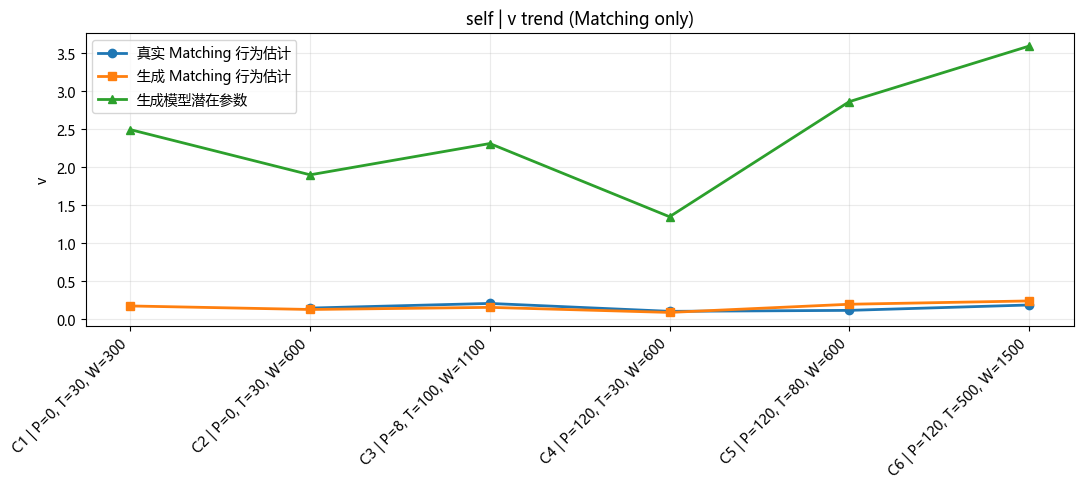

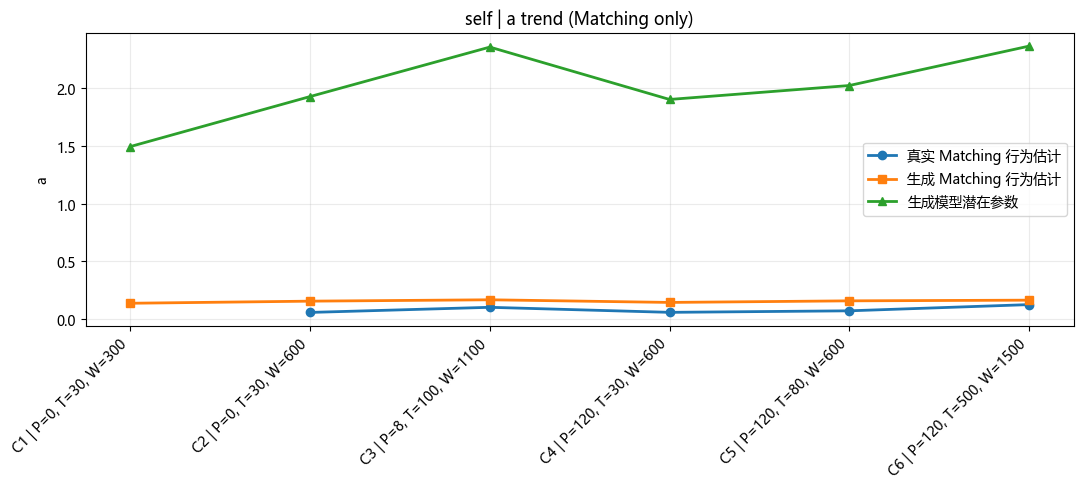

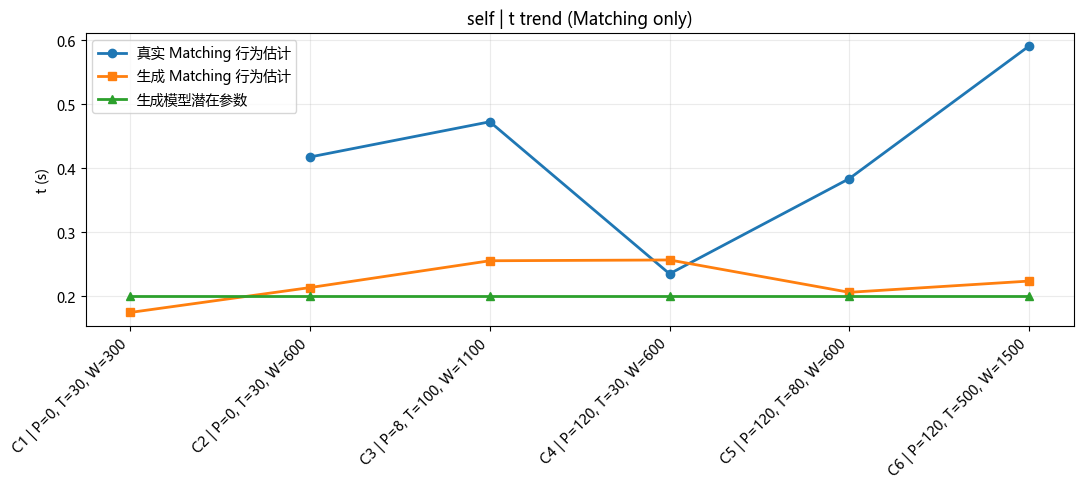

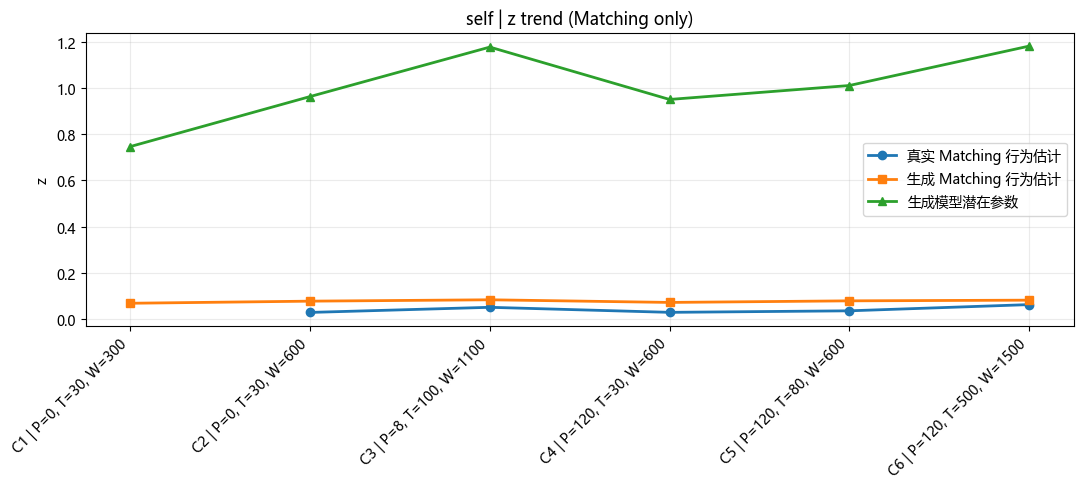

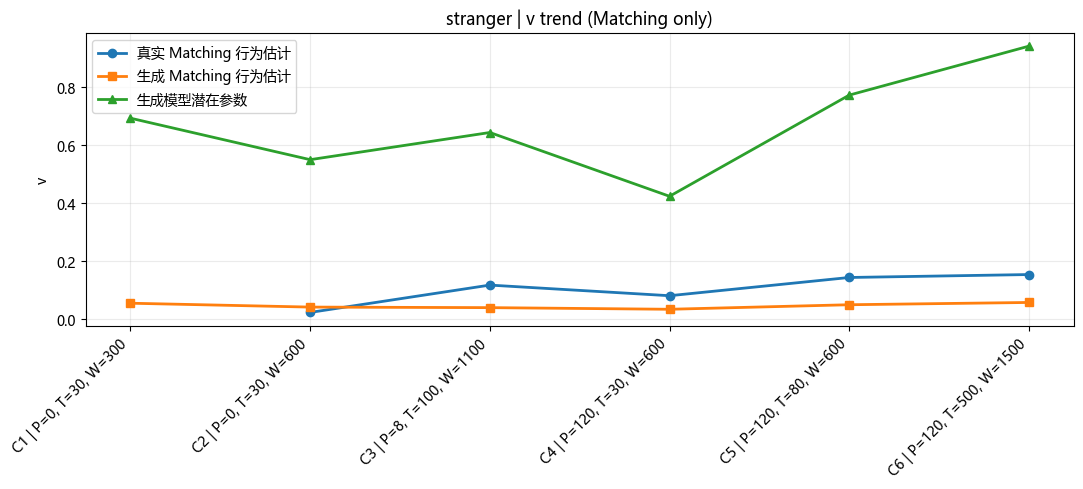

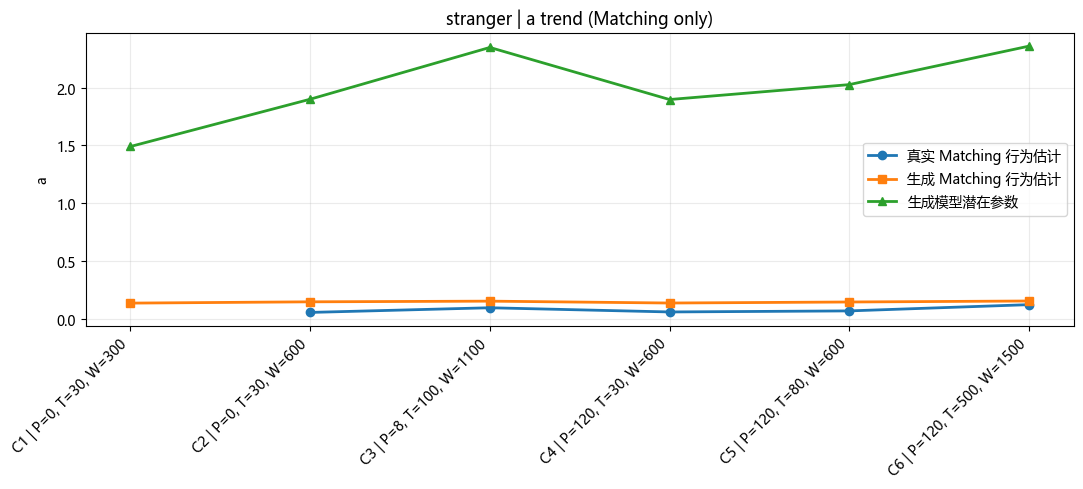

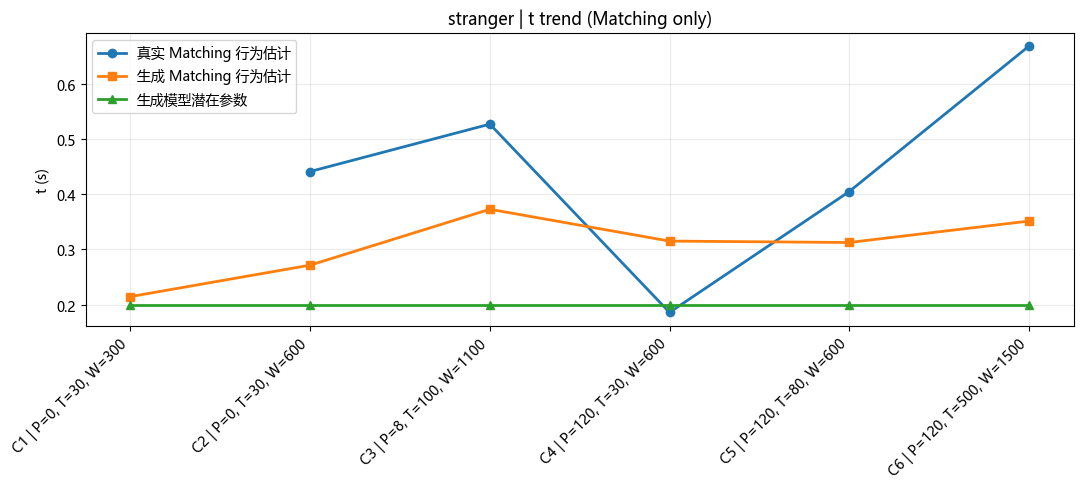

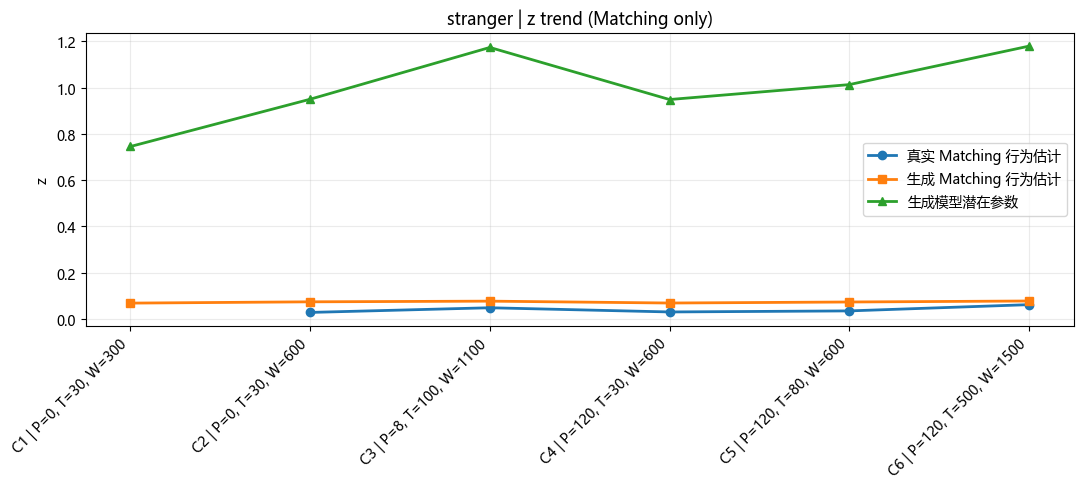

In [14]:
def plot_trend(compare_df, label_value, param, save_name=None):
    mapping = {
        'v': ('v_real', 'v_gen_est', 'v_gen_latent', 'v'),
        'a': ('a_real', 'a_gen_est', 'a_gen_latent', 'a'),
        't': ('t_real', 't_gen_est', 't_gen_latent', 't (s)'),
        'z': ('z_real', 'z_gen_est', 'z_gen_latent', 'z'),
    }
    real_col, gen_est_col, gen_latent_col, ylabel = mapping[param]
    sub = compare_df[compare_df['label'] == label_value].sort_values(['P', 'T_ms', 'W_ms'])
    x = np.arange(len(sub))

    plt.figure(figsize=(11, 5))
    plt.plot(x, sub[real_col], marker='o', linewidth=2, label='真实 Matching 行为估计')
    plt.plot(x, sub[gen_est_col], marker='s', linewidth=2, label='生成 Matching 行为估计')
    plt.plot(x, sub[gen_latent_col], marker='^', linewidth=2, label='生成模型潜在参数')
    plt.xticks(x, sub['condition_text'], rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(f'{label_value} | {param} trend (Matching only)')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(compare_cond['label'].dropna().unique()):
    for param in ['v', 'a', 't', 'z']:
        plot_trend(compare_cond, label, param, save_name=f'{label}_{param}_matching_compare.png')

## 六、按 P / T / W 看边际趋势

这一部分把条件层结果压缩成边际趋势，用来看大方向是否一致。

In [15]:
long_rows = []
for _, row in compare_cond.iterrows():
    for source_name, cols in [
        ('真实 Matching 行为估计', ('v_real', 'a_real', 't_real', 'z_real')),
        ('生成 Matching 行为估计', ('v_gen_est', 'a_gen_est', 't_gen_est', 'z_gen_est')),
        ('生成模型潜在参数', ('v_gen_latent', 'a_gen_latent', 't_gen_latent', 'z_gen_latent')),
    ]:
        long_rows.append({
            'condition_id': row['condition_id'],
            'label': row['label'],
            'P': row['P'],
            'T_ms': row['T_ms'],
            'W_ms': row['W_ms'],
            'source': source_name,
            'v': row[cols[0]],
            'a': row[cols[1]],
            't': row[cols[2]],
            'z': row[cols[3]],
        })
compare_long = pd.DataFrame(long_rows)
display(compare_long.head())

,condition_id,label,P,T_ms,W_ms,source,v,a,t,z
0,C1,self,0.0,30.0,300.0,真实 Matching 行为估计,NaN,NaN,NaN,NaN
1,C1,self,0.0,30.0,300.0,生成 Matching 行为估计,0.173954,0.136845,0.173653,0.068423
2,C1,self,0.0,30.0,300.0,生成模型潜在参数,2.489209,1.493657,0.200000,0.746828
3,C1,stranger,0.0,30.0,300.0,真实 Matching 行为估计,NaN,NaN,NaN,NaN
4,C1,stranger,0.0,30.0,300.0,生成 Matching 行为估计,0.054185,0.135188,0.214622,0.067594


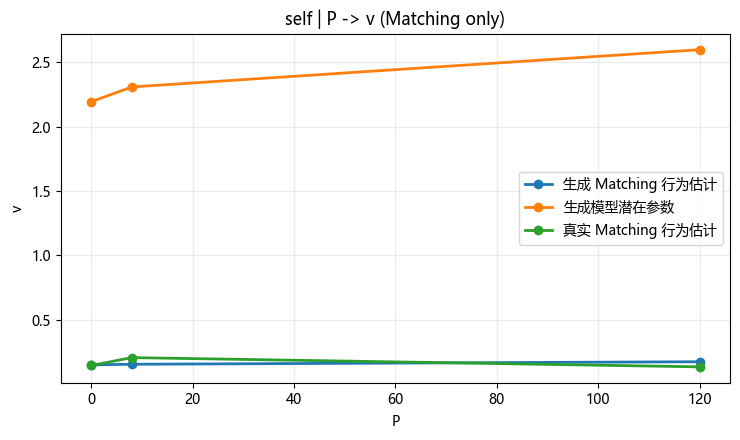

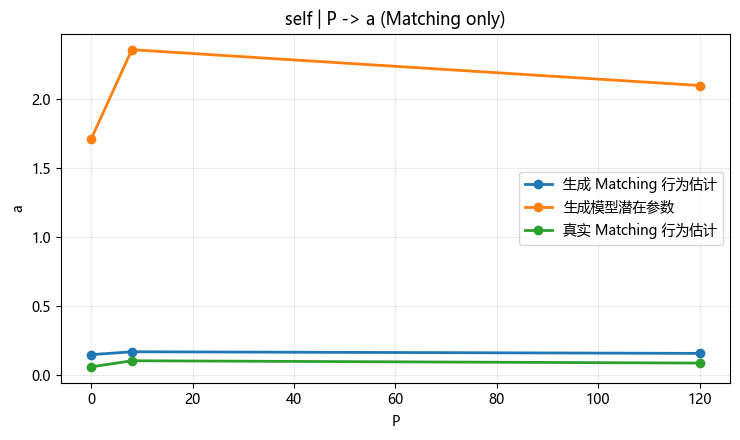

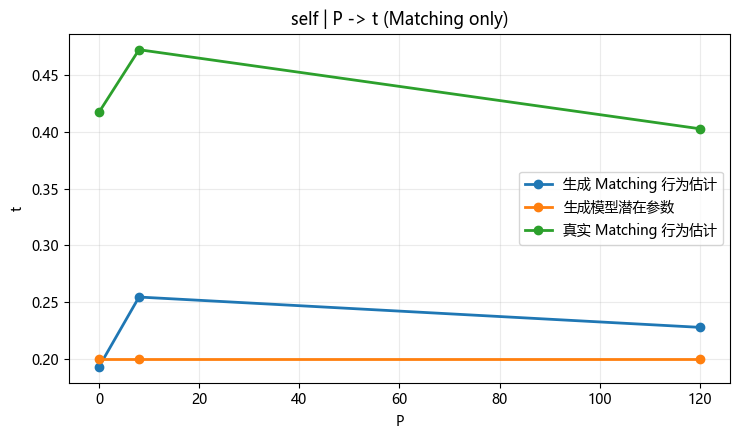

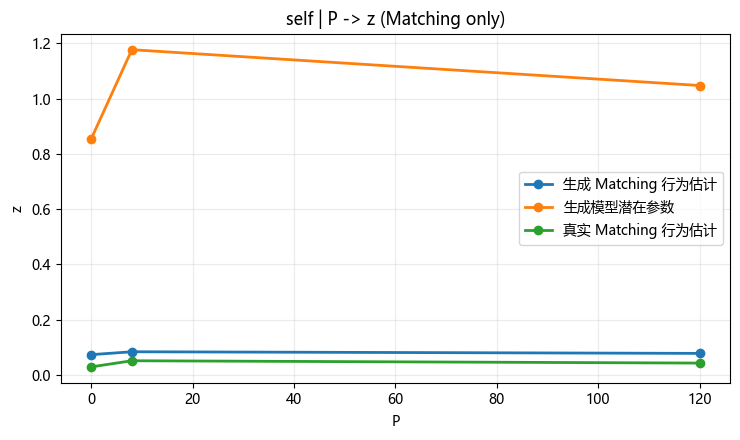

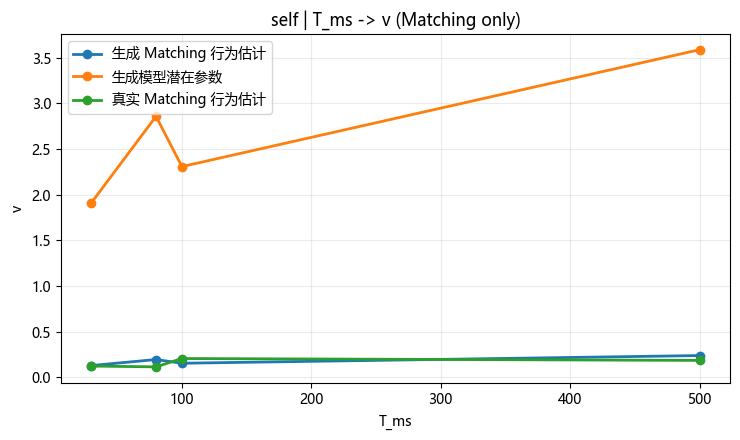

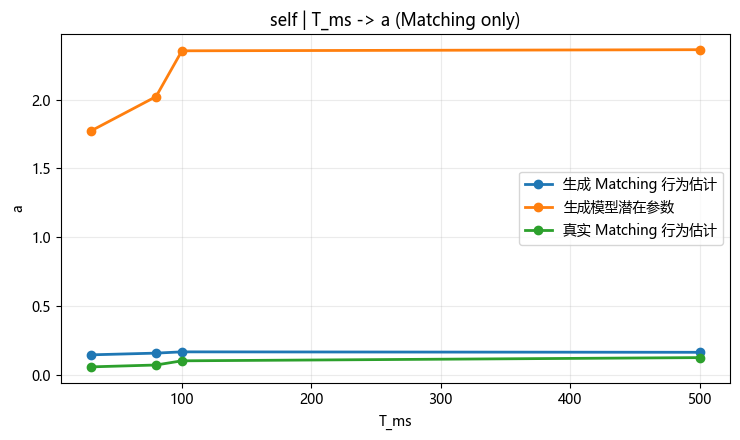

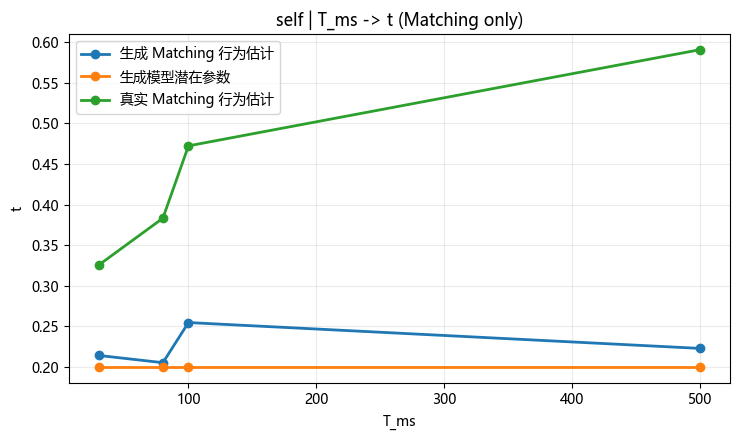

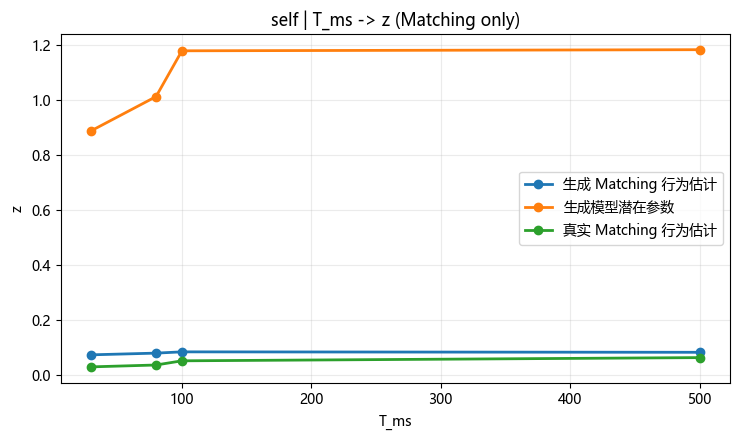

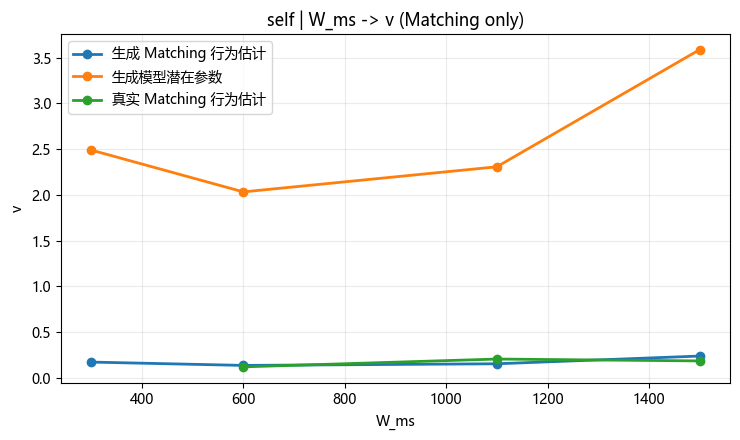

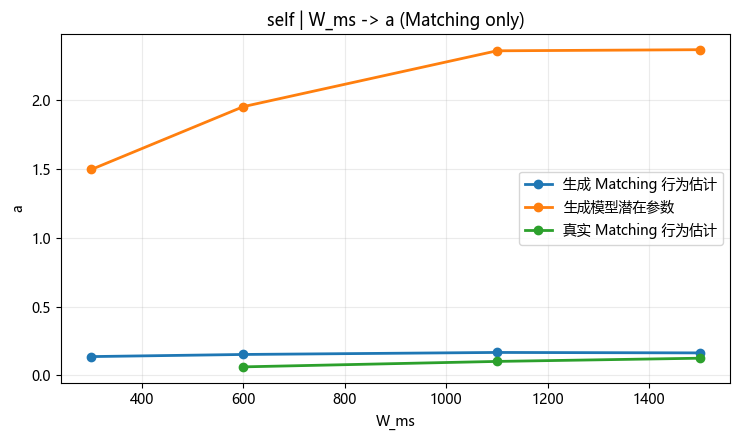

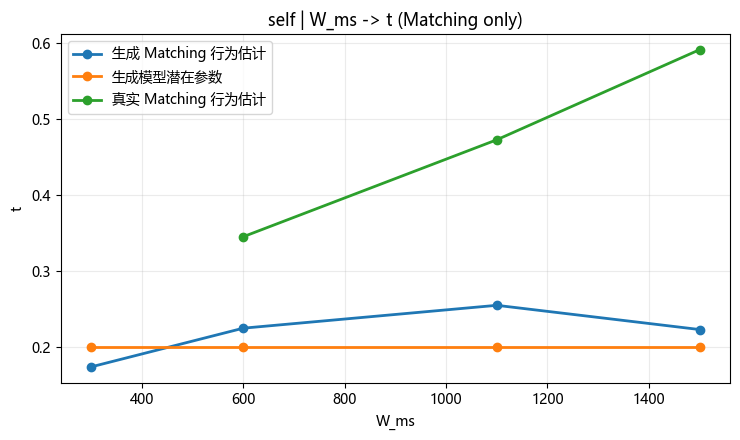

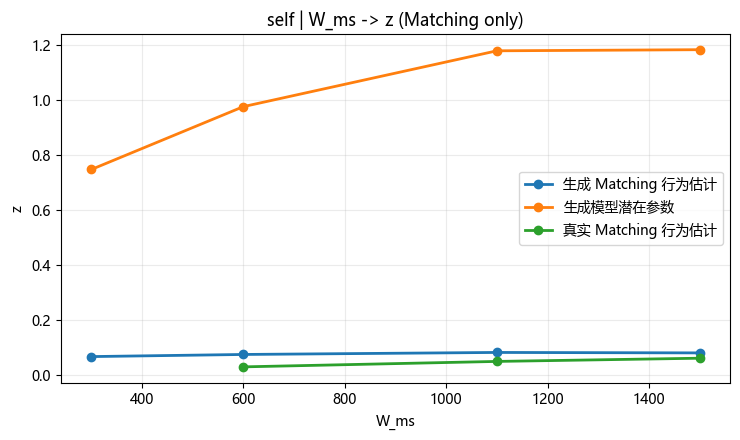

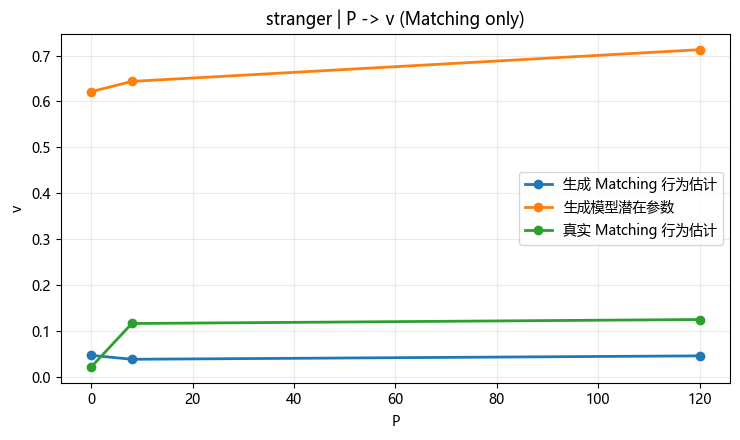

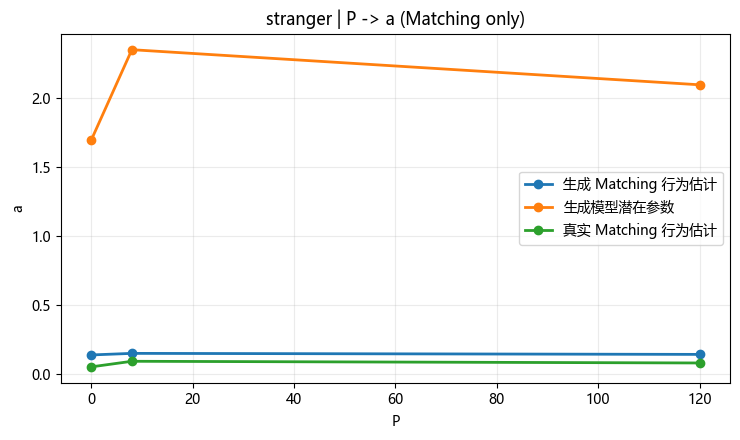

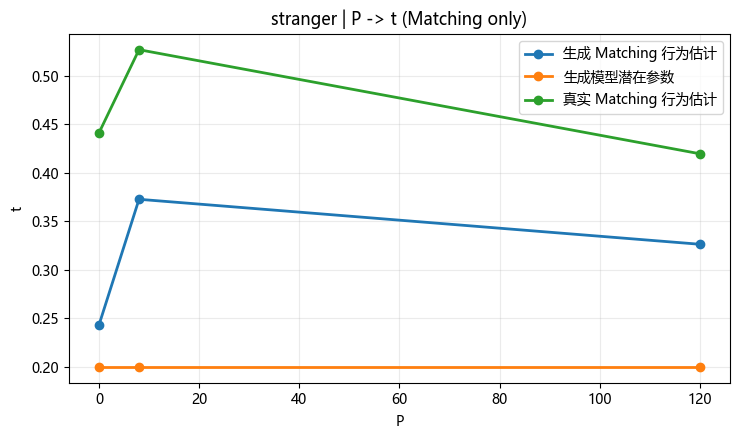

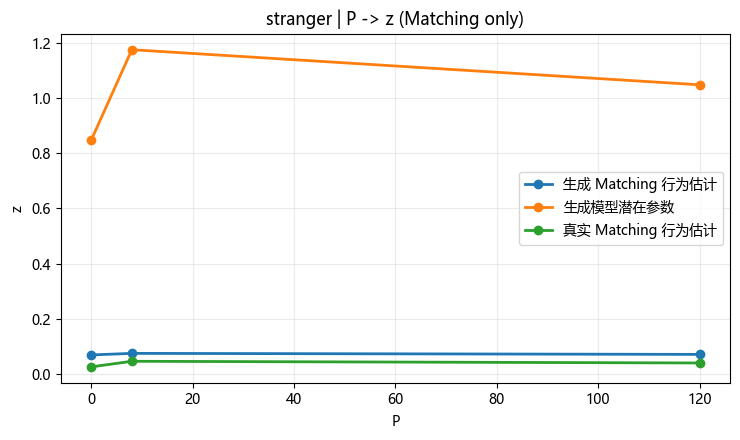

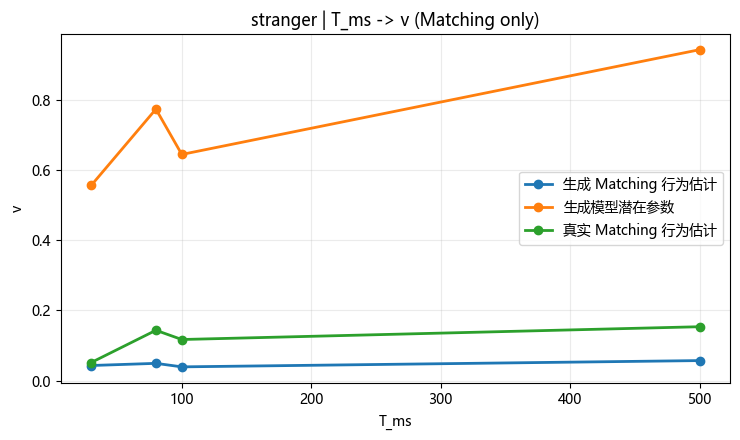

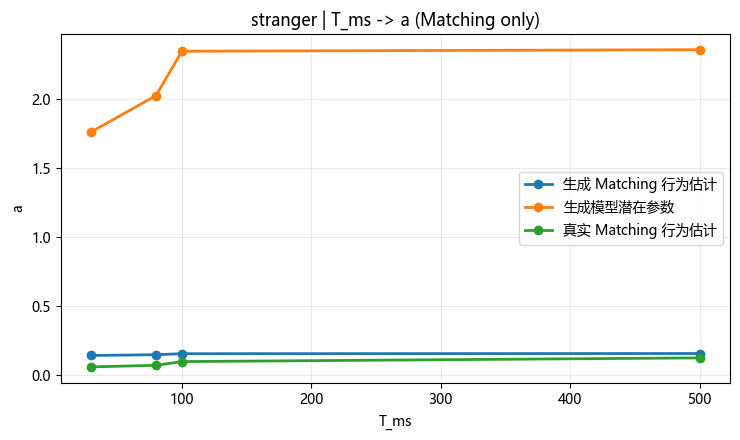

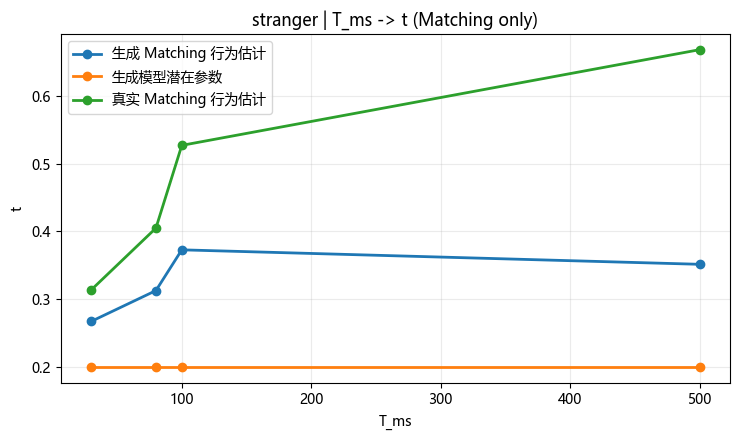

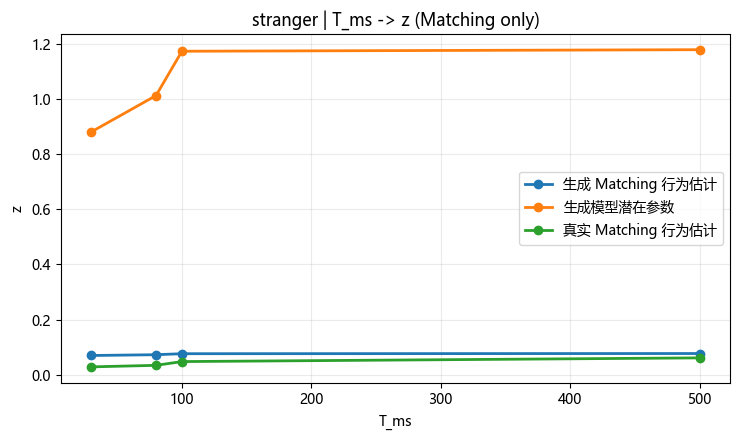

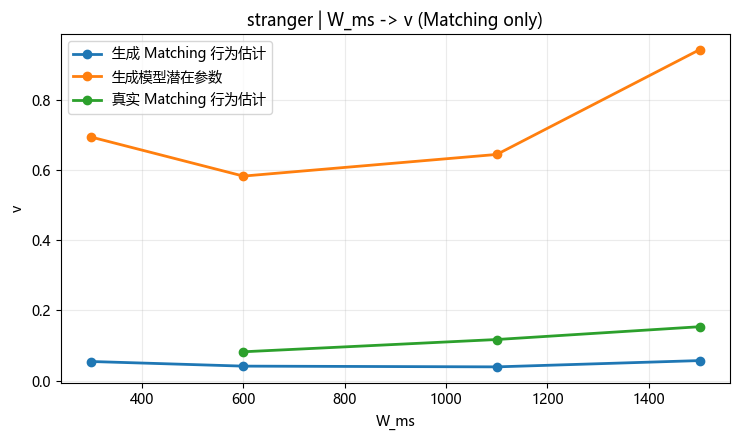

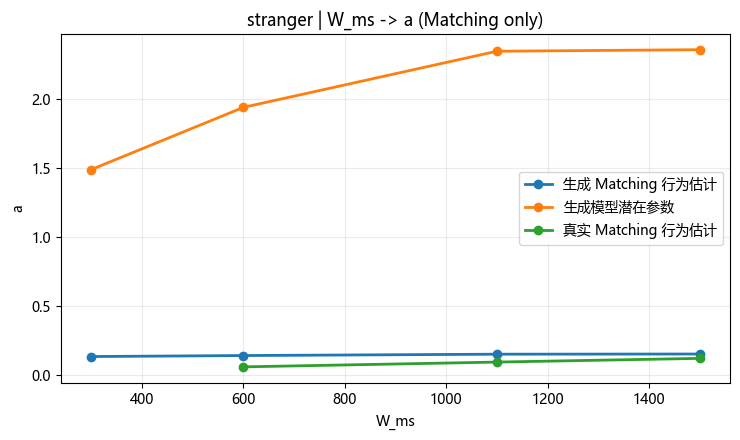

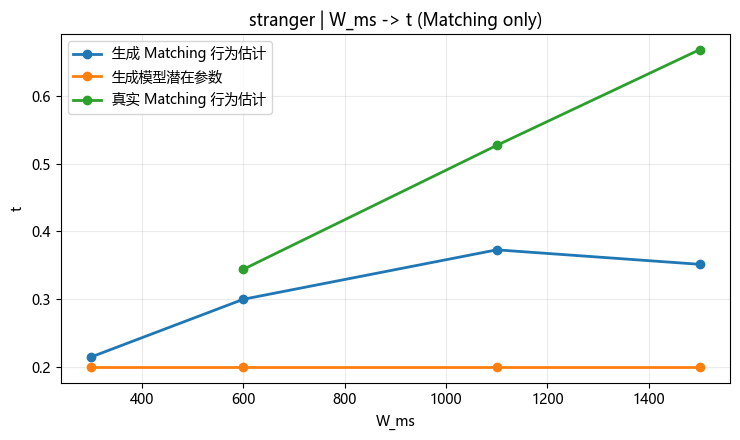

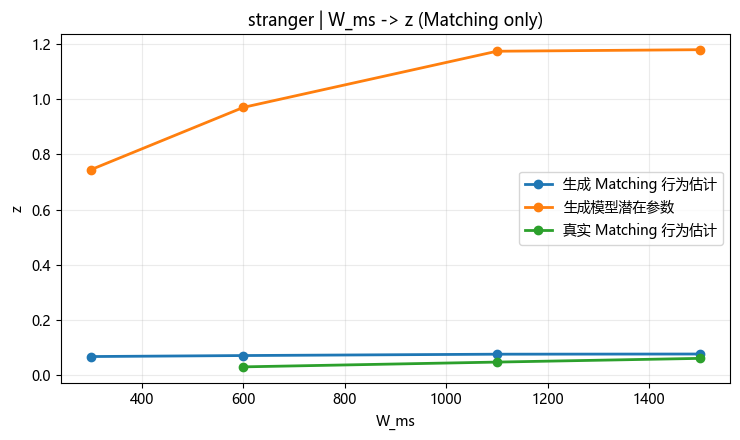

In [16]:
def plot_marginal(df_long, label_value, x_var, param, save_name=None):
    sub = df_long[df_long['label'] == label_value].copy()
    summary = sub.groupby([x_var, 'source'], as_index=False)[param].mean().sort_values([x_var, 'source'])
    plt.figure(figsize=(7.5, 4.5))
    for source_name, part in summary.groupby('source'):
        plt.plot(part[x_var], part[param], marker='o', linewidth=2, label=source_name)
    plt.xlabel(x_var)
    plt.ylabel(param)
    plt.title(f'{label_value} | {x_var} -> {param} (Matching only)')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(compare_long['label'].dropna().unique()):
    for x_var in ['P', 'T_ms', 'W_ms']:
        for param in ['v', 'a', 't', 'z']:
            plot_marginal(compare_long, label, x_var, param, save_name=f'{label}_{x_var}_{param}_matching_marginal.png')

## 七、辅助行为比较：Matching 条件下 RT 与 ACC

In [17]:
real_obs = (
    real_match.groupby(['condition_id', 'label'], as_index=False)
      .agg(P=('P', 'mean'), T_ms=('T_ms', 'mean'), W_ms=('W_ms', 'mean'), RT_real=('rt_s', 'mean'), ACC_real=('correct', 'mean'))
)

gen_obs = (
    gen.groupby(['condition_id', 'label'], as_index=False)
      .agg(P=('P_target', 'mean'), T_ms=('T_ms_target', 'mean'), W_ms=('W_ms_target', 'mean'), RT_gen=('rt_s', 'mean'), ACC_gen=('correct', 'mean'))
)

obs_compare = real_obs.merge(gen_obs, on=['condition_id', 'label', 'P', 'T_ms', 'W_ms'], how='outer').sort_values(['condition_id', 'label']).reset_index(drop=True)
obs_compare['condition_text'] = obs_compare.apply(lambda r: f"{r['condition_id']} | P={int(r['P'])}, T={int(r['T_ms'])}, W={int(r['W_ms'])}", axis=1)
display(obs_compare)

,condition_id,label,P,T_ms,W_ms,RT_real,ACC_real,RT_gen,ACC_gen,condition_text
0,C1,self,0.0,30.0,300.0,0.261308,0.171154,0.484365,0.885579,"C1 | P=0, T=30, W=300"
1,C1,stranger,0.0,30.0,300.0,0.257669,0.168269,0.638348,0.652246,"C1 | P=0, T=30, W=300"
2,C2,self,0.0,30.0,600.0,0.405108,0.313675,0.669182,0.854255,"C2 | P=0, T=30, W=600"
3,C2,stranger,0.0,30.0,600.0,0.410027,0.237607,0.792721,0.610993,"C2 | P=0, T=30, W=600"
4,C3,self,8.0,100.0,1100.0,0.655355,0.874725,0.743385,0.912500,"C3 | P=8, T=100, W=1100"
5,C3,stranger,8.0,100.0,1100.0,0.726035,0.706593,0.996097,0.616071,"C3 | P=8, T=100, W=1100"
6,C4,self,120.0,30.0,600.0,0.368410,0.426154,0.740293,0.777778,"C4 | P=120, T=30, W=600"
7,C4,stranger,120.0,30.0,600.0,0.363301,0.346154,0.805601,0.552490,"C4 | P=120, T=30, W=600"
8,C5,self,120.0,80.0,600.0,0.494703,0.603297,0.585923,0.947931,"C5 | P=120, T=80, W=600"
9,C5,stranger,120.0,80.0,600.0,0.501858,0.428571,0.846110,0.656560,"C5 | P=120, T=80, W=600"


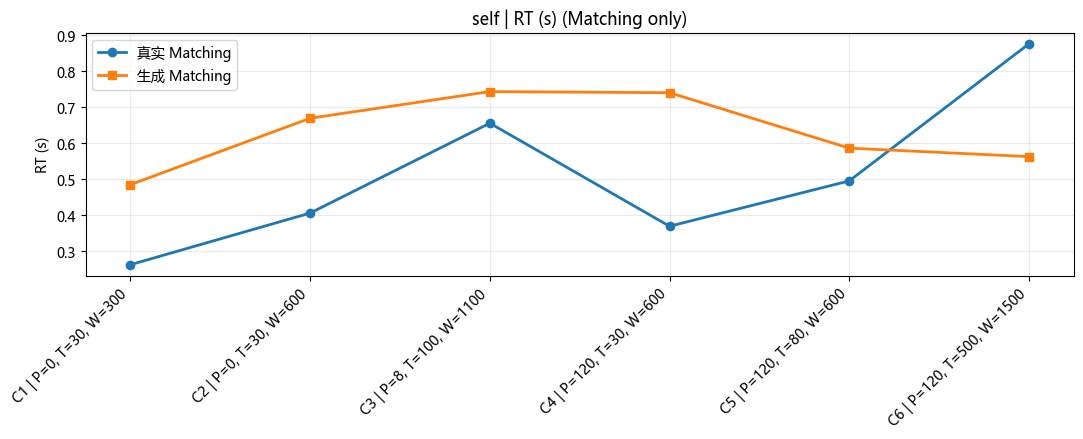

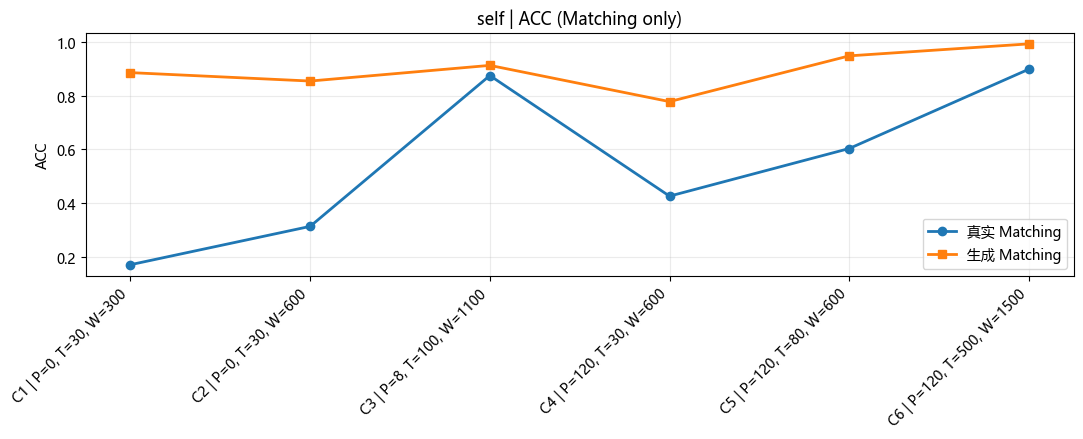

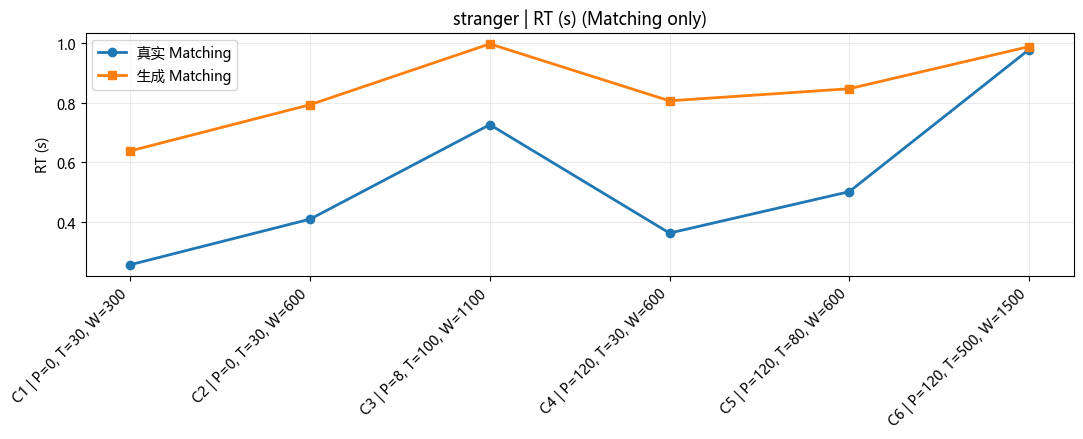

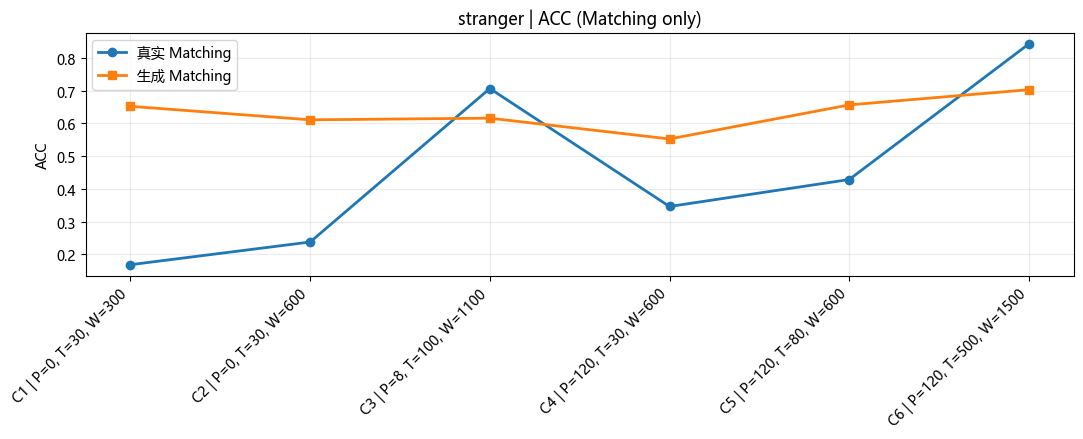

In [18]:
def plot_behavior_compare(df, label_value, real_col, gen_col, ylabel, save_name=None):
    sub = df[df['label'] == label_value].sort_values(['P', 'T_ms', 'W_ms'])
    x = np.arange(len(sub))
    plt.figure(figsize=(11, 4.5))
    plt.plot(x, sub[real_col], marker='o', linewidth=2, label='真实 Matching')
    plt.plot(x, sub[gen_col], marker='s', linewidth=2, label='生成 Matching')
    plt.xticks(x, sub['condition_text'], rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(f'{label_value} | {ylabel} (Matching only)')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(obs_compare['label'].dropna().unique()):
    plot_behavior_compare(obs_compare, label, 'RT_real', 'RT_gen', 'RT (s)', save_name=f'{label}_RT_matching_compare.png')
    plot_behavior_compare(obs_compare, label, 'ACC_real', 'ACC_gen', 'ACC', save_name=f'{label}_ACC_matching_compare.png')

## 八、结论辅助表与输出

In [19]:
summary_table = alignment_df.copy()
summary_table['better_match'] = np.where(
    summary_table['spearman_real_vs_gen_latent'] >= summary_table['spearman_real_vs_gen_est'],
    '生成模型潜在参数更接近真实 Matching 趋势',
    '生成行为估计值更接近真实 Matching 趋势'
)

display(summary_table)

real_export = real.copy()
real_export.to_csv(FIG_DIR / 'real_data_with_matching_column.csv', index=False)
compare_cond.to_csv(FIG_DIR / 'matching_condition_level_param_compare.csv', index=False)
obs_compare.to_csv(FIG_DIR / 'matching_condition_level_rt_acc_compare.csv', index=False)
summary_table.to_csv(FIG_DIR / 'matching_trend_alignment_summary.csv', index=False)

print('已输出到:', FIG_DIR)

,label,param,spearman_real_vs_gen_est,spearman_real_vs_gen_latent,better_match
0,self,v,0.5,0.5,生成模型潜在参数更接近真实 Matching 趋势
1,self,a,0.8,0.9,生成模型潜在参数更接近真实 Matching 趋势
2,self,t,-0.1,NaN,生成行为估计值更接近真实 Matching 趋势
3,self,z,0.8,0.9,生成模型潜在参数更接近真实 Matching 趋势
4,stranger,v,0.7,0.9,生成模型潜在参数更接近真实 Matching 趋势
5,stranger,a,0.7,0.9,生成模型潜在参数更接近真实 Matching 趋势
6,stranger,t,0.5,NaN,生成行为估计值更接近真实 Matching 趋势
7,stranger,z,0.7,0.9,生成模型潜在参数更接近真实 Matching 趋势


已输出到: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Compare_Real_Generated_DDM_Params_v2.4.3_V2


## 九、这版比较逻辑为什么更合理

这版 V2 与上一版相比，更合理的地方在于：

1. **尊重任务范式**：真实实验是经典 Self-Matching Task，因此必须先区分 `Matching / NonMatching`。
2. **尊重生成模型边界**：当前生成模型只模拟 `Matching` 条件下的 `self vs stranger`，所以主比较必须限定在真实数据的 Matching 试次。
3. **使用真实导出信息恢复 Matching**：直接用 `CorrectKey == matchKey` 来恢复 Matching，比死套 shape-label 映射更稳，也更接近实际运行版本。
4. **区分两层比较**：
   - 行为反推参数：真实 Matching vs 生成 Matching
   - 模型潜在参数：真实 Matching 估计值 vs 生成模型内在参数
5. **趋势优先，而非绝对值优先**：这里关注的是 `P / T / W` 调控下参数变化方向与相对形状能否对上，这更符合“模型是否抓住真实机制”的问题。

如果后续你要做更严格的模型拟合检验，下一步最合适的是：

- 在 Matching-only 的真实数据上做正式的层级 DDM / HDDM 拟合；
- 再把拟合得到的后验参数面，与当前生成模型的参数面直接比较。